In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

housing = pd.read_csv("/content/drive/My Drive/Spring 2025/INDENG 165/project_dataset_housing.csv")
housing

Mounted at /content/drive


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
# Data split

df_encoded = pd.get_dummies(housing, drop_first=True)
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
#OLS

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

ols = LinearRegression()
ols.fit(X_train, y_train)

# Prediction
y_pred_ols = ols.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print(f"Test MSE (OLS): {mse_ols:.3e}")

ols_formula = f"y = {ols.intercept_:.2f} + " + " + ".join(f"{coef:.2f}*{name}" for coef, name in zip(ols.coef_, X.columns))
print("Formula:", ols_formula)

Test MSE (OLS): 1.754e+12
Formula: y = 260032.36 + 235.97*area + 76778.70*bedrooms + 1094444.79*bathrooms + 407476.59*stories + 224841.91*parking + 367919.95*mainroad_yes + 231610.04*guestroom_yes + 390251.18*basement_yes + 684649.89*hotwaterheating_yes + 791426.74*airconditioning_yes + 629890.57*prefarea_yes + -126881.82*furnishingstatus_semi-furnished + -413645.06*furnishingstatus_unfurnished


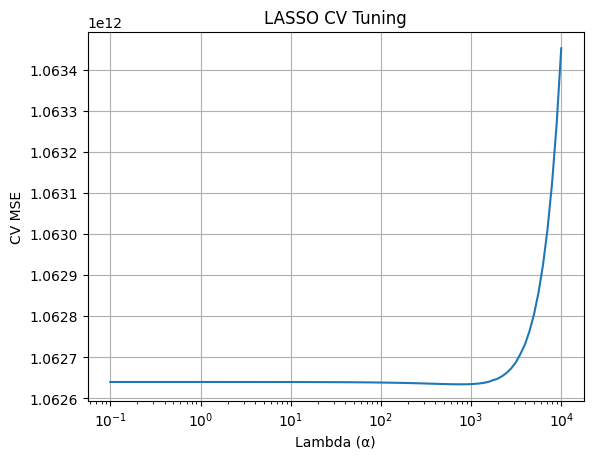

Lambda: 774.2637
MSE (LASSO): 1.76e+12
Formula: y = 4706527.39 + 519384.22*area + 57109.82*bedrooms + 521665.20*bathrooms + 348892.25*stories + 191767.30*parking + 128220.85*mainroad_yes + 88478.89*guestroom_yes + 186637.64*basement_yes + 149073.22*hotwaterheating_yes + 364965.56*airconditioning_yes + 266239.64*prefarea_yes + -61165.53*furnishingstatus_semi-furnished + -190625.78*furnishingstatus_unfurnished


In [5]:
# LASSO

from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt


alphas = np.logspace(-1, 4, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train_scaled, y_train)


y_pred_lasso = lasso_cv.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

plt.plot(lasso_cv.alphas_, np.mean(lasso_cv.mse_path_, axis=1))
plt.xscale('log')
plt.xlabel('Lambda (α)')
plt.ylabel('CV MSE')
plt.title('LASSO CV Tuning')
plt.grid(True)
plt.show()

best_alpha = lasso_cv.alpha_

print(f"Lambda: {best_alpha:.4f}")
print(f"MSE (LASSO): {mse_lasso:.2e}")

feature_names = X.columns
intercept = lasso_cv.intercept_
coefficients = lasso_cv.coef_

# Formula
lasso_terms = [f"{coef:.2f}*{name}" for coef, name in zip(coefficients, feature_names) if abs(coef) > 1e-6]
lasso_formula = f"y = {intercept:.2f} + " + " + ".join(lasso_terms)
print("Formula:", lasso_formula)


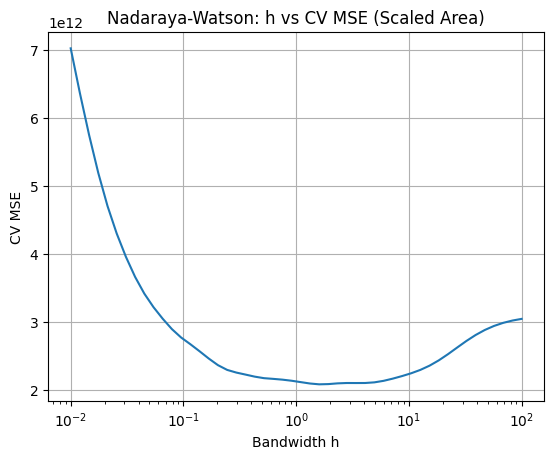

Bandwidth h (scaled): 1.60
MSE (Nadaraya-Watson): 3.70e+12


In [6]:
# Nadaraya-Watson kernel regression
# Select 'area' as feature

from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

X_train_area_scaled = X_train_scaled[:, 0].reshape(-1, 1)
X_test_area_scaled = X_test_scaled[:, 0].reshape(-1, 1)


hs = np.logspace(-2, 2, 50)
cv_errors_nw = []


for h in hs:
    gamma = 1 / (2 * h**2)
    nw_model = KernelRidge(kernel='rbf', gamma=gamma)
    scores = cross_val_score(nw_model, X_train_area_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_errors_nw.append(-scores.mean())


plt.figure()
plt.plot(hs, cv_errors_nw)
plt.xscale('log')
plt.xlabel('Bandwidth h')
plt.ylabel('CV MSE')
plt.title('Nadaraya-Watson: h vs CV MSE (Scaled Area)')
plt.grid(True)
plt.show()


best_h = hs[np.argmin(cv_errors_nw)]
gamma = 1 / (2 * best_h**2)


nw = KernelRidge(kernel='rbf', gamma=gamma)
nw.fit(X_train_area_scaled, y_train)
y_pred_nw = nw.predict(X_test_area_scaled)
mse_nw = mean_squared_error(y_test, y_pred_nw)


print(f"Bandwidth h (scaled): {best_h:.2f}")
print(f"MSE (Nadaraya-Watson): {mse_nw:.2e}")